In [1]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

import numpy as np
import time
import copy
from PIL import Image
import cv2
import open3d as o3d
import importlib
import imutils
import matplotlib.pyplot as plt
from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object, label_wrist_image_rotation_axes
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
from magpie_control import poses
from magpie_control import utils as control_utils
import spatialmath as sm
reload_modules(pcd, utils, real, ur5, gripper, control_utils)
from magpie_control.utils import transform_6d

# rerun viz
import rerun as rr
from rerun_rlds_ur5.rlds import RLDSDataset, DeliGraspTrajectory, LiveRobotData
from rerun_rlds_ur5.rerun_loader_urdf import URDFLogger, get_urdf_paths, update_urdf
reload_modules(LiveRobotData, URDFLogger)
ur5_urdf, _, _= get_urdf_paths("ur5")
rr.init("ScalingForce-visualized", spawn=True)
urdf_logger = URDFLogger(ur5_urdf)
urdf_logger.log()
rr.log("annotation", rr.TextDocument("annotation_1",media_type="text/markdown"))
rerun_viz = LiveRobotData(entity_to_transform=urdf_logger.entity_to_transform)
rr.send_blueprint(rerun_viz.blueprint())

# with help from: https://github.com/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb
import os
from google import genai
import openai
from dotenv import load_dotenv
import instructor
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection, sf_position_thinker
from magpie_prompts import conversation
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)

load_dotenv()
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
OPENAI_API_KEY = os.getenv('CORRELL_API_KEY')
GEMINI_MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}
# OPENAI_MODEL_ID = "gpt-4o-mini"
OPENAI_MODEL_ID = "gpt-4.1-mini"

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)
force_thinker = sf_force_thinker.PromptForceThinker()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.
Module LiveRobotData is not currently imported.
Module URDFLogger is not currently imported.


[2025-04-16T22:24:48Z INFO  re_sdk::spawn] A process is already listening at this address. Assuming it's a Rerun Viewer. addr=0.0.0.0:9876


In [2]:
from magpie_perception.label import Label
from magpie_perception.label_owlvit import LabelOWLViT
from magpie_perception.label_owlv2  import LabelOWLv2
from magpie_perception.label_dino   import LabelDINO
from magpie_perception.mask_sam2    import MaskSAM2

label_models = {'owl-vit': LabelOWLViT(),
                'owl-v2':  LabelOWLv2(),
                'dino':    LabelDINO(),}
mask_models = {'mask': MaskSAM2(),
               'box-dbscan': None}
label_model = label_models['owl-vit']
label_model = label_models['owl-v2']
label_model.init()

/home/will/miniconda3/envs/octo/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=6, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


# Grasp Localization and Initial Motion

In [243]:
user_query = "push the water cup forward 10cm on the table, don't know how much water is in it"
user_query = "tip the bottle onto its edge"
user_query = "push the wheeled chair forward"
user_query = "open the blue case"
# SAVE = False
SAVE = True
STEP = 0
log_time = time.time()
LOG_NAME = f"scalingforce/{user_query}_log_{log_time}"
if not os.path.exists(LOG_NAME):
    os.makedirs(LOG_NAME)
POSITION_MESSAGES, POSITION_RESPONSES, POSITION_MOTION_PLANS = [], [], []
WRENCH_MESSAGES, WRENCH_RESPONSES, WRENCH_MOTION_PLANS = [], [], []

In [184]:
pcd_wrist, rgbd_wrist = wrist.getPCD()
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()

img_wrist = np.array(rgbd_wrist.color).copy()
img_wkspc = np.array(rgbd_wkspc.color)

grasp_prompt = sf_grasp_selection.grasp_prompt.format(**{"user_query": user_query})
img = Image.fromarray(img_wrist)
image_response = gemini_client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[grasp_prompt, img],
)
# image_response = send_message(gemini_client, model=GEMINI_MODEL_ID, messages=[grasp_prompt, img], model_type="gemini")
grasp_phrase = image_response.text.split("\n")[-1].split(": ")[-1]
print(grasp_phrase)


blue case handle


In [ ]:
query = [grasp_phrase]
seg_type = 'box-dbscan'
mask_model = mask_models[seg_type]
pcd_wrist, rgbd_wrist = wrist.getPCD()
pose, pred_image = find_object(rgbd_wrist, query, label_model, mask_model, seg_type, wrist)
np.save(f"{LOG_NAME}/init_moveto_pose.npy", pose)
print(pose)
print(plt.get_backend())
%matplotlib inline
plt.imshow(pred_image)
plt.axis('off')  # Optional: to hide axis values and ticks
plt.show()

In [15]:
# robot.toggle_teach_mode()2

In [154]:
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=6, # 6Hz frequency
                            record=False,
                            provide_gripper=True,
                            provide_ft_sensor=True,)
robot.start()
robot.start_ft_sensor()
# robot.moveL_translation_tooltip(pose, z_offset=0.03, asynch=False)
G = robot.gripper
G.reset_and_close_gripper(5)
robot_pose = robot.getPose().A
np.save(f"{LOG_NAME}/init_robot_pose.npy", robot_pose)


Found Dynamixel Port:
/dev/ttyACM1

Succeeded to open the port
Succeeded to change the baudrate


In [7]:
# robot.moveL(robot.home, asynch=False)

# Physical Reasoning for Forceful Motion Plan

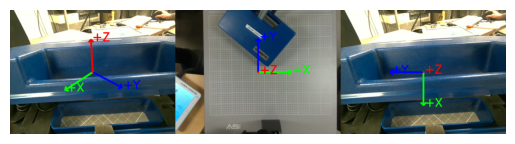

In [244]:
pcd_wkspc, rgbd_wkspc = wkspc.getPCD()
pcd_wrist, rgbd_wrist = wrist.getPCD()
img_wrist = np.array(rgbd_wrist.color)
img_wkspc = np.array(rgbd_wkspc.color)

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
R_wkspc = np.array([[1, 0, 0], [0, -1, 0], [0, 0, -1]])
T_wr = np.array(robot.getPose())
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_labeled = label_wrist_image_rotation_axes(img_wrist.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_labeled_base = label_wrist_image_rotation_axes(img_wrist.copy(), R_cr, intrinsics, axis_length=0.03)
img_wkspc_labeled = label_wrist_image_rotation_axes(img_wkspc.copy(), R_wkspc, intrinsics, axis_length=0.03)
world_only = np.hstack((img_wrist_labeled_base, img_wkspc_labeled))
wrist_only = np.hstack((img_wkspc, img_wrist_labeled))
final_img = np.hstack((img_wrist_labeled_base, img_wkspc_labeled, img_wrist_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = f"{LOG_NAME}/init_axes_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(final_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(final_img)

In [248]:
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
POSITION_MESSAGES, POSITION_RESPONSES, POSITION_MOTION_PLANS = [], [], []
WRENCH_MESSAGES, WRENCH_RESPONSES, WRENCH_MOTION_PLANS = [], [], []
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    model = "gpt-4.1-mini"
    # model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    model = GEMINI_MODEL_ID

prompt_config = {
"obj": grasp_phrase,
"task": user_query
}

position_img = Image.fromarray(world_only)
position_prompt = sf_position_thinker.prompt_position_thinker.format(**prompt_config)
# position_prompt = sf_force_thinker.prompt_base_frame_thinker.format(**prompt_config)
POSITION_MESSAGES = build_messages(position_prompt, position_img, messages=POSITION_MESSAGES, model_type=model_type)
position_response = send_message(client, model, POSITION_MESSAGES, model_type=model_type)
position_motion_plan = force_thinker.process_thinker_response(position_response)
print(position_response)
POSITION_MESSAGES = build_messages(position_response, image=None, messages=POSITION_MESSAGES, model_type=model_type, role="assistant")
POSITION_RESPONSES = build_messages(position_response, image=None, messages=POSITION_RESPONSES, model_type=model_type)
POSITION_MOTION_PLANS = build_messages(position_motion_plan, image=None, messages=POSITION_MOTION_PLANS, model_type=model_type)
print(position_motion_plan)


pose = robot.getPose().A
R = pose[:3, :3]
p_world = np.array(position_motion_plan["world_motion_vector"])
p_wrist = R.T @ p_world
position_motion_plan["wrist_motion_vector"] = list(p_wrist.round(4))
np.save(f"{LOG_NAME}/position_response-{STEP}.npy", position_response, allow_pickle=True)
np.save(f"{LOG_NAME}/position_motion_plan-{STEP}.npy", position_motion_plan, allow_pickle=True)
# combine prompt_config dict with position_motion_plan dict
wrench_prompt_config = {**prompt_config, **position_motion_plan}

wrench_img = Image.fromarray(final_img)
wrench_prompt = sf_force_thinker.prompt_force_thinker.format(**wrench_prompt_config)
WRENCH_MESSAGES = build_messages(wrench_prompt, wrench_img, messages=WRENCH_MESSAGES, model_type=model_type)
wrench_response = send_message(client, model, WRENCH_MESSAGES, model_type=model_type)
wrench_motion_plan = force_thinker.process_thinker_response(wrench_response)
np.save(f"{LOG_NAME}/wrench_response-{STEP}.npy", wrench_response, allow_pickle=True)
np.save(f"{LOG_NAME}/wrench_motion_plan-{STEP}.npy", wrench_motion_plan, allow_pickle=True)
print(wrench_response)
WRENCH_MESSAGES = build_messages(wrench_response, image=None, messages=WRENCH_MESSAGES, model_type=model_type, role="assistant")
WRENCH_RESPONSES = build_messages(wrench_response, image=None, messages=WRENCH_RESPONSES, model_type=model_type)
WRENCH_MOTION_PLANS = build_messages(wrench_motion_plan, image=None, messages=WRENCH_MOTION_PLANS, model_type=model_type)
print(wrench_motion_plan)

[start of position motion plan]
The task is to open the blue case while grasping the blue case handle.

Aligning Images With World Frame Motion:
The provided images in the two-part image confirm the blue case and handle are present on the table, and that the object appears to have a hinge to enable it to open. The blue case is likely made of plastic, and has low mass.
The red axis representing the world Z-axis corresponds to upward (positive) and downward (negative) motion in the world. 
To complete the task, the object in the image should have upward and positive linear motion along the Z-axis with magnitude 0.1 meters.
The green axis representing the world X-axis corresponds to left (positive) and right (negative) motion in the world, relative to the robot. 
To complete the task, the object in the image should have no linear motion along the X-axis with magnitude 0.0 meters.
The blue axis representing the world Y-axis corresponds to backward (positive) and forward (negative) motion i

In [249]:
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message
POSITION_MESSAGES, POSITION_RESPONSES, POSITION_MOTION_PLANS = [], [], []
WRENCH_MESSAGES, WRENCH_RESPONSES, WRENCH_MOTION_PLANS = [], [], []
model_type = "gemini"
# model_type = "openai"
client, model = None, None
if model_type == "openai":
    client = openai_client
    model = "gpt-4.1-mini"
    # model = OPENAI_MODEL_ID
elif model_type == "gemini":
    client = gemini_client
    model = GEMINI_MODEL_ID

prompt_config = {
"obj": grasp_phrase,
"task": user_query
}

position_img = Image.fromarray(world_only)
position_prompt = sf_force_thinker.prompt_base_frame_thinker.format(**prompt_config)
position_response = send_message(client, model, POSITION_MESSAGES, model_type=model_type)
position_motion_plan = force_thinker.process_thinker_response(position_response)
print(position_response)
POSITION_MESSAGES = build_messages(position_response, image=None, messages=POSITION_MESSAGES, model_type=model_type, role="assistant")
POSITION_RESPONSES = build_messages(position_response, image=None, messages=POSITION_RESPONSES, model_type=model_type)
POSITION_MOTION_PLANS = build_messages(position_motion_plan, image=None, messages=POSITION_MOTION_PLANS, model_type=model_type)
print(position_motion_plan)

wrench_motion_plan = position_motion_plan.copy()
wrench_base = position_motion_plan['ft_vector']
wrench_wrist = transform_6d(wrench_base, T_wr, pose_to_origin=False, is_wrench=True)
print(f"wrench_base: {wrench_base}")
print(f"wrench_wrist: {wrench_wrist}")
p_base = position_motion_plan['world_motion_vector']
p_wrist = R_wr.T @ p_base
print(f"p_base: {p_base}")
print(f"p_wrist: {p_wrist}")
wrench_motion_plan['wrench'] = wrench_wrist
position_motion_plan['wrist_motion_vector'] = p_wrist
np.save(f"{LOG_NAME}/wrench_motion_plan-{STEP}.npy", wrench_motion_plan, allow_pickle=True)
np.save(f"{LOG_NAME}/position_response-{STEP}.npy", position_response, allow_pickle=True)
np.save(f"{LOG_NAME}/position_motion_plan-{STEP}.npy", position_motion_plan, allow_pickle=True)
position_motion_plan

ValueError: contents are required.

In [239]:
robot.ctrl.disconnect()

In [240]:
robot.ctrl.reconnect()
robot.toggle_teach_mode()


In [247]:
robot.toggle_teach_mode()

# Robot Motion Execution

In [241]:
G.reset_parameters()

In [246]:
importlib.reload(ur5)
importlib.reload(gripper)
# ROBOT_IP = "192.168.0.4"
# robot = ur5.UR5_Interface(ROBOT_IP, 
#                             freq=6, # 6Hz frequency
#                             record=False,
#                             provide_gripper=True,
#                             provide_ft_sensor=True,)
# robot.start()
robot.start_ft_sensor(poll_rate=100)
G = robot.gripper
# G.reset_parameters()
# np.save(f"{LOG_NAME}/init_home.npy", robot.home)
# pose = np.load(f"{LOG_NAME}/init_moveto_pose.npy")
G.reset_and_close_gripper(force_limit=10)
time.sleep(0.375)

In [237]:
import numpy as np
position_motion_plan = np.load(f"{LOG_NAME}/position_motion_plan-{STEP}.npy", allow_pickle=True).item()
wrench_motion_plan = np.load(f"{LOG_NAME}/wrench_motion_plan-{STEP}.npy", allow_pickle=True).item()
G.reset_and_close_gripper(force_limit=10)
time.sleep(0.25)

camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}
goal_delta = np.array(position_motion_plan["wrist_motion_vector"])
# direction = np.array(motion_plan['position_direction'])
# sign = np.where(np.hstack((direction, np.zeros(3))) < 0, -1, 1)
# wrench = np.array(wrench_motion_plan['wrench']) * sign 
wrench = np.array(wrench_motion_plan['wrench'])
wrench_goal = wrench * -1
# wrench_goal = wrench
init_cmd = np.hstack((wrench[:3] / 100, wrench[3:] / 5))
duration = wrench_motion_plan['duration'] * 2
grasp_force = wrench_motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005

# TODO: add a re-zero ft sensor function, but for now just restart it
robot.start_ft_sensor()

print(init_cmd)
print(wrench_goal)

motion_log = await robot.concurrent_gripper_camera_robot_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, 
                                        #  camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, rerun_viz=rerun_viz,
                                         camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, rerun_viz=None,
                                        #  duration=duration, p=P, control_type="bang_bang")
                                         duration=duration, p=P, control_type="proportional")
robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)
# STEP += 1

[ 0.05 -0.05 -0.05  0.    0.1   0.  ]
[-5.   5.   5.  -0.  -0.5 -0. ]
D405 Recording Started
D435 Recording Started
Error reading from OptoForce!
D405 Recording Task Cancelled
D405 Recording Stopped
D435 Recording Task Cancelled
D435 Recording Stopped


True

In [242]:
if SAVE:
    import time
    import os
    episode_time = time.time()
    episode_name = f"{LOG_NAME}/episode_{STEP}_{episode_time}"
    position_messages = [i for i in POSITION_MESSAGES if type(i) == str]
    wrench_messages = [i for i in WRENCH_MESSAGES if type(i) == str]
    # create directory if it doesn't exist
    if not os.path.exists(episode_name):
        os.makedirs(episode_name)
    np.save(f"{episode_name}/query_image.npy", final_img, allow_pickle=True)
    np.save(f"{episode_name}/position_messages.npy", position_messages, allow_pickle=True)
    np.save(f"{episode_name}/wrench_messages.npy", wrench_messages, allow_pickle=True)
    np.save(f"{episode_name}/gripper_log.npy", motion_log['gripper'],allow_pickle=True)
    np.save(f"{episode_name}/robot_log.npy", motion_log['robot'],allow_pickle=True)
    np.save(f"{episode_name}/wrist_log.npy", motion_log['record/wrist/'],allow_pickle=True)
    np.save(f"{episode_name}/wkspc_log.npy", motion_log['record/workspace/'],allow_pickle=True)

In [224]:
for key in motion_log:
    ts = motion_log[key].keys()
    last_ts = sorted(ts)[-1]
    first_ts = sorted(ts)[0]
    print(f"sensor {key} first timestamp: {first_ts}")
    print(f"sensor {key} last timestamp: {last_ts}")
    duration = last_ts - first_ts
    length = len(motion_log[key])
    print(f"sensor {key} duration: {duration}, length: {length}, Hz: {length/duration}\n")

sensor gripper first timestamp: 1744847349.1234386
sensor gripper last timestamp: 1744847355.0543337
sensor gripper duration: 5.930895090103149, length: 36, Hz: 6.069910098405381

sensor robot first timestamp: 1744847349.0609322
sensor robot last timestamp: 1744847355.053941
sensor robot duration: 5.993008852005005, length: 290, Hz: 48.38971661171139

sensor record/wrist/ first timestamp: 1744847348.9509246
sensor record/wrist/ last timestamp: 1744847355.0847514
sensor record/wrist/ duration: 6.133826732635498, length: 39, Hz: 6.358184164625566

sensor record/workspace/ first timestamp: 1744847348.7742279
sensor record/workspace/ last timestamp: 1744847354.9543543
sensor record/workspace/ duration: 6.180126428604126, length: 38, Hz: 6.148741524788331



# Feedback

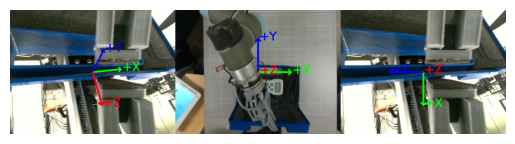

In [225]:
gripper_log = motion_log['gripper'].copy()
robot_log   = motion_log['robot'].copy()
wrist_log   = motion_log['record/wrist/']
wkspc_log   = motion_log['record/workspace/']
gripper_ts   = sorted(gripper_log.keys())
robot_ts     = sorted(robot_log.keys())
wrist_ts     = sorted(wrist_log.keys())
wkspc_ts     = sorted(wkspc_log.keys())

R_cw = np.array([ # camera to wrist
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
])
T_wr = np.array(sm.SE3(poses.pose_vec_to_mtrx(np.array(robot_log[robot_ts[-1]]['actual_TCP_pose']))))
R_wr = T_wr[:3, :3]
R_cr = R_cw @ R_wr.T
intrinsics = np.load("scalingforce/intrinsic_matrix.npy", allow_pickle=True)
img_wrist_final = wrist_log[wrist_ts[-1]]['rgb']
img_wkspc_final = wkspc_log[wkspc_ts[-1]]['rgb']
img_wrist_final_labeled = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cw, intrinsics, axis_length=0.03)
img_wrist_final_labeled_base = label_wrist_image_rotation_axes(img_wrist_final.copy(), R_cr, intrinsics, axis_length=0.03)
img_wkspc_final_labeled = label_wrist_image_rotation_axes(img_wkspc_final.copy(), R_wkspc, intrinsics, axis_length=0.03)
if STEP <= 1:
    prev_position_img = world_only
    prev_img = final_img
else:
    prev_position_img = feedback_position_img
    prev_img = feedback_img
feedback_position_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final_labeled))
feedback_img = np.hstack((img_wrist_final_labeled_base, img_wkspc_final_labeled, img_wrist_final_labeled))
# final_img = np.hstack((wrist_img_labeled, wrist_img2_labeled, ))

# save img
fn = f"{LOG_NAME}/axes_step-{STEP}_{user_query}.png"
cv2.imwrite(fn, cv2.cvtColor(feedback_img, cv2.COLOR_RGB2BGR))

plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.imshow(feedback_img)

In [105]:
from spatialmath.base import rodrigues, tr2rpy
import numpy as np

motion_report = ""
position_motion_report = ""
motion_report += f"Initial Position Motion Plan: {position_motion_plan}\n"
motion_report += f"Initial Wrench Motion Plan: {wrench_motion_plan}\n"
position_motion_report += f"Initial Position Motion Plan: {position_motion_plan}\n"
# get first and last TCP pose of robot log
first_pose = np.array(robot_log[robot_ts[0]]['actual_TCP_pose'])
last_pose =  np.array(robot_log[robot_ts[-1]]['actual_TCP_pose'])
dist =  last_pose - first_pose
# get the rotation matrix from the wrist frame to the robot frame
rot = rodrigues(first_pose[3:6])
# transform distance to be relative to the first TCP wrist frame, use inverse of rot
dist_wrist = rot.T @ dist[:3]
motion_report += f"Motion Plan Results: \nDistance traveled relative to original wrist base frame [x, y, z] (m) axes: {dist_wrist.round(3)}\n"
position_motion_report += f"Motion Plan Results: \nDistance traveled relative to original wrist base frame [x, y, z] (m) axes: {dist_wrist.round(3)}\n"
motion_report += f"Distance traveled along base frame [x, y, z] (m) axes: {dist[:3].round(3)}\n"
position_motion_report += f"Distance traveled along base frame [x, y, z] (m) axes: {dist[:3].round(3)}\n"

# Use a simple moving average with a window size of downsample_factor
def moving_average(data, window_size):
    return np.array([np.mean(data[i:i+window_size], axis=0) for i in range(0, len(data), window_size)])

def get_report(desired_freq, timestamps, log, name, description):
    log_dur = timestamps[-1] - timestamps[0]
    log_flat = np.array([log[i][name] for i in timestamps])
    num_downsampled_entries = int(log_dur // (1 / desired_freq))
    downsample_factor = len(timestamps) // num_downsampled_entries
    downsampled_log = moving_average(log_flat, downsample_factor)
    summary = f"\n{description} Log Summary:"
    summary += f"\nMotion Duration: {log_dur}s"
    summary += f"\nAverage {name} Downsampled at {desired_freq}Hz:"
    for i, entry in enumerate(downsampled_log):
        summary += f"\n{i*(1/desired_freq)}s to {(i+1)*(1/desired_freq)}: {entry.round(2)}"
    summary += f"\nOverall Average Across Episode: {np.mean(downsampled_log, axis=0).round(2)}"
    return summary
desired_freq = 2
# flip the sign of all the wrenches because LLMs do not understand action/reaction
for i in robot_ts:
    robot_log[i]['wrench'] = -1 * np.array(robot_log[i]['wrench'])
wrench_report = get_report(desired_freq, robot_ts, robot_log, "wrench", "6D Wrench [x, y, z, rx, ry, rz] (N and Nm)")
# print(wrench_report)
motion_report += f"{wrench_report}\n"

gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_l", "Left Gripper Contact Force (N)")
motion_report += f"{gripper_report}\n"
gripper_report = get_report(desired_freq, gripper_ts, gripper_log, "cf_r", "Right Gripper Contact Force (N)")
# print(gripper_report)
motion_report += f"{gripper_report}\n"

print(motion_report)
print(position_motion_report)

Initial Position Motion Plan: {'world_motion_description': 'The object must be moved to the left and slightly backward in the world frame to turn the chair to the left.', 'world_motion_direction': [1, 1, 0], 'world_motion_magnitude': [0.2, 0.15, 0.0], 'world_motion_vector': [0.2, 0.15, 0.0], 'wrist_motion_vector': array([0.247, 0.003, 0.037])}
Initial Wrench Motion Plan: {'wrench_description': 'Apply forces to turn the chair to the left while grasping the backrest support, requiring linear motion along X and Y axes to overcome friction, and a torque around the Z axis to rotate the chair, and a slight movement into the page.', 'wrench': [30.0, 2.0, 0.5, -0.1, 0.1, 8.0], 'grasp_force': 18.0, 'duration': 5.0}
Motion Plan Results: 
Distance traveled relative to original wrist base frame [x, y, z] (m) axes: [ 0.145  0.113 -0.015]
Distance traveled along base frame [x, y, z] (m) axes: [0.176 0.003 0.057]

6D Wrench [x, y, z, rx, ry, rz] (N and Nm) Log Summary:
Motion Duration: 4.999337196350

In [59]:
from magpie_prompts.prompts import sf_force_thinker, sf_grasp_selection, sf_force_reflection, sf_position_thinker
from magpie_prompts import conversation
reload_modules(sf_force_thinker, sf_grasp_selection, sf_position_thinker, conversation, sf_force_reflection)
from magpie_prompts.conversation import openai_encode_image, build_messages, send_message

position_feedback_messages = POSITION_RESPONSES.copy() # pass by reference now to keep history
# position_feedback_messages = [str(POSITION_MOTION_PLANS.copy())] # TODO: make this work
position_feedback_prompt_config = prompt_config.copy()
position_feedback_prompt_config['position_motion_report'] = position_motion_report
position_feedback_prompt = sf_position_thinker.prompt_position_reflection.format(**position_feedback_prompt_config)
position_img_feedback_PIL = Image.fromarray(feedback_position_img).convert("RGB")
position_img_previous_PIL = Image.fromarray(prev_position_img).convert("RGB")

POSITION_MESSAGES = build_messages(position_feedback_prompt, position_img_feedback_PIL,messages=POSITION_MESSAGES, model_type=model_type)
position_feedback_messages = build_messages("This is the previous image, taken prior to execution of the robot motion plan", 
                                   position_img_previous_PIL, messages=position_feedback_messages, model_type=model_type)
position_feedback_messages = build_messages(position_feedback_prompt, position_img_feedback_PIL, messages=position_feedback_messages, model_type=model_type)
print(position_feedback_messages)
position_feedback_response = send_message(client, model, position_feedback_messages, model_type=model_type)
POSITION_MESSAGES = build_messages(position_feedback_response, image=None, messages=POSITION_MESSAGES, model_type=model_type, role="assistant")
POSITION_RESPONSES = build_messages(position_feedback_response, image=None, messages=POSITION_RESPONSES, model_type=model_type)

print(position_feedback_response)
position_reflector = sf_position_thinker.PromptPositionThinker()
position_motion_feedback_plan = position_reflector.process_thinker_response(position_feedback_response)
POSITION_MOTION_PLANS = build_messages(position_motion_feedback_plan, image=None, messages=POSITION_MOTION_PLANS, model_type=model_type)
np.save(f"{LOG_NAME}/position_response-{STEP}.npy", position_feedback_response, allow_pickle=True)
np.save(f"{LOG_NAME}/position_motion_plan-{STEP}.npy", position_motion_feedback_plan, allow_pickle=True)
print(position_motion_feedback_plan)

['[start of position motion plan]\nThe task is to open the blue case lid while grasping the blue case lid top.\n\nAligning Images With World Frame Motion:\nThe provided images in the two-part image confirm the blue case and the blue case lid. The task is to open the lid by grasping the top of the lid. I assume the lid is hinged along the side closer to the positive X axis.\nThe red axis representing the world Z-axis corresponds to upward (positive) and downward (negative) motion in the world. \nTo complete the task, the object in the image must perform upward and positive motion along the Z-axis with magnitude 0.1 meters.\nThe green axis representing the world X-axis corresponds to left (positive) and right (negative) motion in the world, relative to the robot. \nTo complete the task, the object in the image must perform no motion along the X-axis with magnitude 0.0 meters.\nThe blue axis representing the world Y-axis corresponds to backward (positive) and forward (negative) motion in 

In [ ]:
wrench_feedback_messages = WRENCH_MOTION_PLANS.copy()  # pass by reference now to keep history
wrench_feedback_prompt_config = {**prompt_config.copy(), **position_motion_feedback_plan}
wrench_feedback_prompt_config['motion_report'] = motion_report
wrench_feedback_prompt = sf_force_reflection.prompt_motion_reflection.format(**wrench_feedback_prompt_config)
wrench_img_feedback_PIL = Image.fromarray(feedback_img).convert("RGB")
wrench_img_previous_PIL = Image.fromarray(prev_img).convert("RGB")

WRENCH_MESSAGES = build_messages(wrench_feedback_prompt, wrench_img_feedback_PIL, messages=WRENCH_MESSAGES, model_type=model_type)
wrench_feedback_messages = build_messages(
    "This is the previous image, taken prior to execution of the robot motion plan",
    wrench_img_previous_PIL,
    messages=wrench_feedback_messages,
    model_type=model_type
)
wrench_feedback_messages = build_messages(wrench_feedback_prompt, wrench_img_feedback_PIL, messages=wrench_feedback_messages, model_type=model_type)
wrench_feedback_response = send_message(client, model, wrench_feedback_messages, model_type=model_type)

WRENCH_MESSAGES = build_messages(wrench_feedback_response, image=None, messages=WRENCH_MESSAGES, model_type=model_type, role="assistant")
WRENCH_RESPONSES = build_messages(wrench_feedback_response, image=None, messages=WRENCH_RESPONSES, model_type=model_type)

print(wrench_feedback_response)
wrench_reflector = sf_force_reflection.PromptForceReflector()
wrench_motion_feedback_plan = wrench_reflector.process_thinker_response(wrench_feedback_response)

WRENCH_MOTION_PLANS = build_messages(wrench_motion_feedback_plan, image=None, messages=WRENCH_MOTION_PLANS, model_type=model_type)
np.save(f"{LOG_NAME}/wrench_response-{STEP}.npy", wrench_feedback_response, allow_pickle=True)
np.save(f"{LOG_NAME}/wrench_motion_plan-{STEP}.npy", wrench_motion_feedback_plan, allow_pickle=True)
print(wrench_motion_feedback_plan)

In [106]:
for i in feedback_messages:
    print(i)

[start of motion plan]
The task is to push the water cup forward 10cm on the table, don't know how much water is in it while grasping the transparent body of cup.

Aligning Images With Wrist Motion:
The provided images in the three-part image confirm the object is a light-colored, likely clear, cup on a table with a gridded surface. The environment includes other objects, but only the cup is relevant. The task requires pushing the cup forward.
The green axis representing the positive X-axis along the wrist corresponds to pushing the cup away from the robot in the world frame.
The blue axis representing negative Y-axis along the wrist corresponds to moving the cup to the right from the robot's perspective in the world frame.
The red dot representing the positive Z-axis (into the page) along the wrist corresponds to moving the cup upwards in the world frame.
Thus, in order to complete the task, the required linear wrist motion along the green axis representing the positive X-axis is posi